In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

### Read Decision Forests Results

In [10]:
fn = f"../results/OnlinePAFM/GBT_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_arr = data["pregrets_online"]
PREGRETS_random_arr = data["pregrets_offline"]


fn = f"../results/RL/online_pregrets_fqi.npz"
data = np.load(fn)
print(data)
PREGRETS_RL_arr = data["pregret_list_time"]
PREGRETS_random_RL_arr = data["pregret_list_notime"]
Ts_RL = data["t_list"]


step = 6
Ts_DF = [2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/DF/RF_oh_w_time128_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5,normalization=True)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization=True)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)



NpzFile '../results/RL/online_pregrets_fqi.npz' with keys: pregret_list_notime, pregret_list_time, t_list
(10, 13)


In [12]:
Ts_RL

array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100,
       1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200,
       2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300,
       3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400,
       4500, 4600, 4700, 4800, 4900, 5000])

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_38907/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


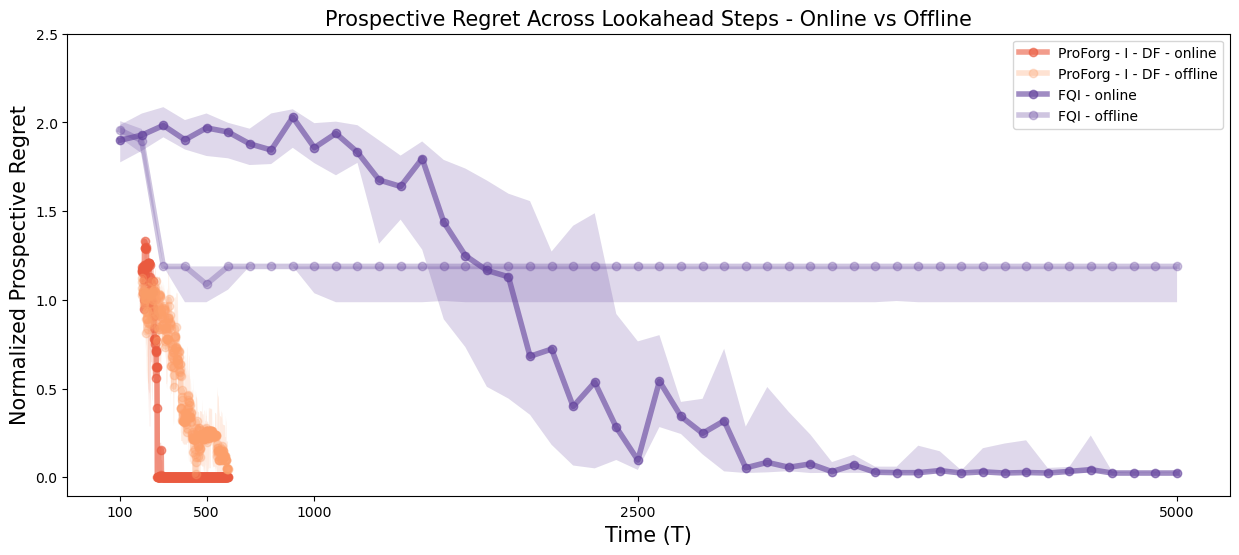

In [17]:
plt.figure(figsize=(15, 6))

linewidth = 4
fontsize = 15
pafm_df_offline, pafm_df, pafm_df_online = get_close_colors("OrRd", start = 0.45, delta = 0.2 , n = 3) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,_ = get_close_colors("Purples", start=0.8, delta=0.5,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PAFM_RF_online": pafm_df,
          "PAFM_RF_offline":pafm_df_offline,
          "PAFM_RF":pafm_df,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn,
          "RL_FQI":rl_fqi,
          "RL_TQL":rl_tql
          }

Ts_online = np.arange(200,600,1)
median = np.median(PREGRETS_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg - I - DF - online')
plt.fill_between(Ts_online, q25, q75, color=colors["PAFM_RF_online"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_arr, 75, axis=0)
plt.plot(Ts_online, median,color=colors["PAFM_RF_offline"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - I - DF - offline')
plt.fill_between(Ts_online, q25, q75, color=colors["PAFM_RF_offline"], alpha=0.20, edgecolor="none")


median = np.median(PREGRETS_RL_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_RL_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_RL_arr, 75, axis=0)
plt.plot(Ts_RL, median,color=colors["RL_FQI"], lw = linewidth,marker='o',alpha = 0.6,label = 'FQI - online')
plt.fill_between(Ts_RL, q25, q75, color=colors["RL_FQI"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_RL_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_RL_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_RL_arr, 75, axis=0)
plt.plot(Ts_RL, median,color=colors["RL_FQI"], lw = linewidth,marker='o',alpha = 0.3,label = 'FQI - offline')
plt.fill_between(Ts_RL, q25, q75, color=colors["RL_FQI"], alpha=0.20, edgecolor="none")


# median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
# plt.plot(Ts_DF, median,color=colors["PAFM_RF"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - offline')
# plt.fill_between(Ts_DF, q25, q75, color=colors["PAFM_RF"], alpha=0.20, edgecolor="none")


# xticks = Ts_online + Ts_DF
# xticklabels = [str(v) if v in [128,256,512] else "" 
#                for i, v in enumerate(xticks)]

# plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)
plt.xticks([100,500,1000,2500,5000])
# plt.xscale('log')
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
plt.title('Prospective Regret Across Lookahead Steps - Online vs Offline',fontsize = fontsize)
plt.legend()